# ВКР: Предсказание популярности музыкального трека
## Level 3: Аудио-признаки (Librosa + VGGish + CLAP)

**Вход:** `dataset_clean.csv` (из Level 1)  
**Выход:** `audio_features.csv` (librosa + VGGish + CLAP + индексы)  

**Три типа аудио-признаков:**
- **L3a: Librosa** (handcrafted) — MFCC, хромаграмма, спектральные, ~105 признаков
- **L3b: VGGish** (learned, classification) — CNN обученная на AudioSet, 128D
- **L3c: CLAP** (learned, contrastive) — мультимодальная модель (аудио-текст), 512D

**Кеширование:** каждые 500 треков. Можно прервать и продолжить.

---
## 1. Импорт

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import librosa
import os, re, requests, json, pickle, time, joblib
from tqdm import tqdm
from urllib.parse import quote
import warnings; warnings.filterwarnings('ignore')

import torch

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    roc_auc_score, classification_report, accuracy_score, f1_score
)

plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')

print(f'PyTorch: {torch.__version__}')
print(f'CUDA: {torch.cuda.is_available()} ({torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU"})')
print('OK')

PyTorch: 2.5.1+cu121
CUDA: True (NVIDIA GeForce GTX 1650 SUPER)
OK


In [2]:
df = pd.read_csv('dataset_clean.csv')
df['explicit'] = df['explicit'].astype(int)
target = 'popularity'
print(f'Датасет: {len(df):,} треков')

Датасет: 81,207 треков


---
## 2. Скачивание аудио (Deezer API)

Search + download атомарно (токен превью истекает за ~5 минут).  
Кеш: `download_cache.json` каждые 500 треков.

In [3]:
def normalize_name(name):
    if not isinstance(name, str): return ''
    name = re.sub(r'\s*[\(\[].*?[\)\]]', '', name)
    name = re.sub(r'\s*-\s*(Remastered|Remaster|Deluxe|Radio Edit|Single Version|Bonus Track).*', '', name, flags=re.IGNORECASE)
    name = re.sub(r'\s*feat\.?\s+.*', '', name, flags=re.IGNORECASE)
    name = re.sub(r'\s*ft\.?\s+.*', '', name, flags=re.IGNORECASE)
    return name.strip()

def first_artist(name):
    if not isinstance(name, str): return ''
    return re.split(r'[,;&]|\sfeat\.?\s|\sft\.?\s|\sx\s|\svs\.?\s', name, flags=re.IGNORECASE)[0].strip()

def search_and_download(track_name, artist_name, filepath):
    queries = [
        f'{artist_name} {track_name}',
        f'{first_artist(artist_name)} {normalize_name(track_name)}',
        normalize_name(track_name),
    ]
    for query in queries:
        query = query.strip()
        if not query or len(query) < 3: continue
        try:
            resp = requests.get(f'https://api.deezer.com/search?q={quote(query)}&limit=3', timeout=10)
            if resp.status_code != 200: continue
            for item in resp.json().get('data', []):
                preview_url = item.get('preview', '')
                if not preview_url or len(preview_url) < 20: continue
                audio = requests.get(preview_url, timeout=15)
                if audio.status_code == 200 and len(audio.content) > 500:
                    with open(filepath, 'wb') as f:
                        f.write(audio.content)
                    return True
        except: pass
        time.sleep(0.15)
    return False

AUDIO_DIR = 'audio_previews'
os.makedirs(AUDIO_DIR, exist_ok=True)
ok = search_and_download('Billie Jean', 'Michael Jackson', f'{AUDIO_DIR}/test.mp3')
print(f'Тест Deezer: {"OK" if ok else "FAIL"}')

Тест Deezer: OK


In [4]:
DOWNLOAD_CACHE = 'download_cache.json'
FAILED_CACHE = 'download_failed.json'

# Загрузка кеша с защитой от повреждений
audio_index_map = {}
failed_set = set()

if os.path.exists(DOWNLOAD_CACHE):
    try:
        with open(DOWNLOAD_CACHE) as f:
            audio_index_map = {int(k): v for k, v in json.load(f).items()}
        print(f'Кеш скачанных: {len(audio_index_map):,}')
    except json.JSONDecodeError:
        print('⚠️ Кеш повреждён! Восстанавливаем из файлов...')
        for fname in os.listdir(AUDIO_DIR):
            if fname.startswith('track_') and fname.endswith('.mp3'):
                fpath = os.path.join(AUDIO_DIR, fname)
                if os.path.getsize(fpath) > 500:
                    idx = int(fname.replace('track_', '').replace('.mp3', ''))
                    audio_index_map[idx] = fpath
        with open(DOWNLOAD_CACHE, 'w') as f:
            json.dump({str(k): v for k, v in audio_index_map.items()}, f)
        print(f'✅ Восстановлено: {len(audio_index_map):,}')

if os.path.exists(FAILED_CACHE):
    try:
        with open(FAILED_CACHE) as f:
            failed_set = set(json.load(f))
        print(f'Пропущенных: {len(failed_set):,}')
    except: pass

print(f'Осталось скачать: {len(df) - len(audio_index_map) - len(failed_set):,}')

Кеш скачанных: 78,597
Пропущенных: 2,944
Осталось скачать: -334


In [5]:
to_download = {idx: row for idx, row in df.iterrows()
               if idx not in audio_index_map and idx not in failed_set}
print(f'В кеше: {len(audio_index_map):,}, failed: {len(failed_set):,}')
print(f'Скачиваем: {len(to_download):,} треков\n')

success = len(audio_index_map); fail = len(failed_set)
for idx, row in tqdm(to_download.items(), total=len(to_download)):
    filepath = os.path.join(AUDIO_DIR, f'track_{idx}.mp3')
    if os.path.exists(filepath) and os.path.getsize(filepath) > 500:
        audio_index_map[idx] = filepath; success += 1; continue
    ok = search_and_download(row.get('track_name',''), row.get('artists',''), filepath)
    if ok: audio_index_map[idx] = filepath; success += 1
    else: failed_set.add(idx); fail += 1
    if (success+fail) % 10 == 0: time.sleep(0.2)
    if (success+fail) % 100 == 0: time.sleep(1)
    if (success+fail) % 500 == 0:
        time.sleep(3)
        with open(DOWNLOAD_CACHE,'w') as f: json.dump({str(k):v for k,v in audio_index_map.items()}, f)
        with open(FAILED_CACHE,'w') as f: json.dump(list(failed_set), f)
        tqdm.write(f'  💾 OK:{success:,} Fail:{fail:,}')

with open(DOWNLOAD_CACHE,'w') as f: json.dump({str(k):v for k,v in audio_index_map.items()}, f)
with open(FAILED_CACHE,'w') as f: json.dump(list(failed_set), f)
print(f'\nСкачано: {len(audio_index_map):,}/{len(df):,} ({len(audio_index_map)/len(df)*100:.1f}%)')

В кеше: 78,597, failed: 2,944
Скачиваем: 0 треков



0it [00:00, ?it/s]


Скачано: 78,597/81,207 (96.8%)


---
## 3. Librosa (handcrafted, ~105 признаков)

In [6]:
def extract_librosa_features(filepath, sr=22050):
    try:
        y, sr = librosa.load(filepath, sr=sr, duration=30)
        if len(y) < sr*2: return None
        f = {}
        mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=20)
        for i in range(20): f[f'mfcc_{i}_mean'],f[f'mfcc_{i}_std'] = np.mean(mfcc[i]),np.std(mfcc[i])
        chroma = librosa.feature.chroma_stft(y=y, sr=sr)
        for i in range(12): f[f'chroma_{i}_mean'],f[f'chroma_{i}_std'] = np.mean(chroma[i]),np.std(chroma[i])
        for nm,fn in [('spectral_centroid',librosa.feature.spectral_centroid),('spectral_bandwidth',librosa.feature.spectral_bandwidth),('spectral_rolloff',librosa.feature.spectral_rolloff)]:
            v=fn(y=y,sr=sr)[0]; f[f'{nm}_mean'],f[f'{nm}_std']=np.mean(v),np.std(v)
        sc=librosa.feature.spectral_contrast(y=y,sr=sr)
        for i in range(sc.shape[0]): f[f'spectral_contrast_{i}_mean'],f[f'spectral_contrast_{i}_std']=np.mean(sc[i]),np.std(sc[i])
        sf=librosa.feature.spectral_flatness(y=y)[0]; f['spectral_flatness_mean'],f['spectral_flatness_std']=np.mean(sf),np.std(sf)
        rm=librosa.feature.rms(y=y)[0]; f['rms_mean'],f['rms_std']=np.mean(rm),np.std(rm)
        zc=librosa.feature.zero_crossing_rate(y=y)[0]; f['zcr_mean'],f['zcr_std']=np.mean(zc),np.std(zc)
        tempo,_=librosa.beat.beat_track(y=y,sr=sr); f['librosa_tempo']=float(np.atleast_1d(tempo)[0])
        oe=librosa.onset.onset_strength(y=y,sr=sr); f['onset_strength_mean'],f['onset_strength_std']=np.mean(oe),np.std(oe)
        tn=librosa.feature.tonnetz(y=y,sr=sr)
        for i in range(6): f[f'tonnetz_{i}_mean'],f[f'tonnetz_{i}_std']=np.mean(tn[i]),np.std(tn[i])
        return f
    except: return None

LIBROSA_CACHE = 'librosa_cache.pkl'
librosa_dict = {}
if os.path.exists(LIBROSA_CACHE):
    with open(LIBROSA_CACHE,'rb') as f: librosa_dict = pickle.load(f)
    print(f'Librosa кеш: {len(librosa_dict):,}')
to_process = {k:v for k,v in audio_index_map.items() if k not in librosa_dict}
print(f'Осталось: {len(to_process):,}')

Librosa кеш: 78,586
Осталось: 11


In [7]:
for i, (idx, fp) in enumerate(tqdm(to_process.items(), total=len(to_process), desc='Librosa')):
    feat = extract_librosa_features(fp)
    if feat: librosa_dict[idx] = feat
    if (i+1) % 500 == 0:
        with open(LIBROSA_CACHE,'wb') as f: pickle.dump(librosa_dict, f)
        tqdm.write(f'  💾 Librosa: {len(librosa_dict):,}')
with open(LIBROSA_CACHE,'wb') as f: pickle.dump(librosa_dict, f)
librosa_names = sorted(list(list(librosa_dict.values())[0].keys()))
print(f'Librosa: {len(librosa_dict):,} треков, {len(librosa_names)} признаков')

Librosa: 100%|████████████████████████████████| 11/11 [00:02<00:00,  3.88it/s]


Librosa: 78,586 треков, 105 признаков


---
## 4. VGGish (learned, classification-based, 128D)

In [8]:
print('Загружаем VGGish (PyTorch Hub)...')
vggish_model = torch.hub.load('harritaylor/torchvggish', 'vggish')
vggish_model.eval()
print('✅ VGGish загружен')

def extract_vggish_embedding(filepath):
    try:
        y, sr = librosa.load(filepath, sr=16000, mono=True, duration=30)
        if len(y) < sr*2: return None
        emb = vggish_model.forward(y, sr)
        return emb.detach().cpu().numpy().mean(axis=0)  # (128,)
    except: return None

test_emb = extract_vggish_embedding(list(audio_index_map.values())[0])
print(f'Тест: shape={test_emb.shape}' if test_emb is not None else '❌')

Загружаем VGGish (PyTorch Hub)...


Using cache found in C:\Users\nikit/.cache\torch\hub\harritaylor_torchvggish_master


✅ VGGish загружен
Тест: shape=(128,)


In [9]:
VGGISH_CACHE = 'vggish_cache.pkl'
vggish_dict = {}
if os.path.exists(VGGISH_CACHE):
    with open(VGGISH_CACHE,'rb') as f: vggish_dict = pickle.load(f)
    print(f'VGGish кеш: {len(vggish_dict):,}')
to_proc_v = {k:v for k,v in audio_index_map.items() if k not in vggish_dict}
print(f'Осталось: {len(to_proc_v):,}')

for i, (idx, fp) in enumerate(tqdm(to_proc_v.items(), total=len(to_proc_v), desc='VGGish')):
    emb = extract_vggish_embedding(fp)
    if emb is not None: vggish_dict[idx] = emb
    if (i+1) % 500 == 0:
        with open(VGGISH_CACHE,'wb') as f: pickle.dump(vggish_dict, f)
        tqdm.write(f'  💾 VGGish: {len(vggish_dict):,}')
with open(VGGISH_CACHE,'wb') as f: pickle.dump(vggish_dict, f)
print(f'VGGish: {len(vggish_dict):,} треков, 128 признаков')

VGGish кеш: 78,586
Осталось: 11


VGGish: 100%|████████████████████████████████| 11/11 [00:00<00:00, 354.85it/s]


VGGish: 78,586 треков, 128 признаков


---
## 5. CLAP (learned, contrastive, 512D)

**CLAP** (Contrastive Language-Audio Pretraining) — мультимодальная модель Microsoft.  
Обучена на парах "аудио-текст" по принципу CLIP: аудио и текст проецируются в общее пространство.  
В отличие от VGGish (classification-based), CLAP понимает семантику звука через контрастивное обучение.

In [10]:
import sys
!{sys.executable} -m pip install msclap


[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [11]:
from msclap import CLAP

print('Загружаем CLAP...')
clap_model = CLAP(version='2023', use_cuda=torch.cuda.is_available())
print('✅ CLAP загружен')

def extract_clap_embedding(filepath):
    try:
        emb = clap_model.get_audio_embeddings([filepath])
        return emb[0].detach().cpu().numpy()  # (512,)
    except:
        return None

test_clap = extract_clap_embedding(list(audio_index_map.values())[0])
print(f'Тест: shape={test_clap.shape}' if test_clap is not None else '❌')

Загружаем CLAP...
✅ CLAP загружен
Тест: shape=(1024,)


In [12]:
CLAP_CACHE = 'clap_cache.pkl'
clap_dict = {}
if os.path.exists(CLAP_CACHE):
    with open(CLAP_CACHE,'rb') as f: clap_dict = pickle.load(f)
    print(f'CLAP кеш: {len(clap_dict):,}')
to_proc_c = {k:v for k,v in audio_index_map.items() if k not in clap_dict}
print(f'Осталось: {len(to_proc_c):,}')

for i, (idx, fp) in enumerate(tqdm(to_proc_c.items(), total=len(to_proc_c), desc='CLAP')):
    emb = extract_clap_embedding(fp)
    if emb is not None: clap_dict[idx] = emb
    if (i+1) % 500 == 0:
        with open(CLAP_CACHE,'wb') as f: pickle.dump(clap_dict, f)
        tqdm.write(f'  💾 CLAP: {len(clap_dict):,}')
with open(CLAP_CACHE,'wb') as f: pickle.dump(clap_dict, f)
print(f'CLAP: {len(clap_dict):,} треков, {len(test_clap)} признаков')

CLAP кеш: 78,597
Осталось: 0


CLAP: 0it [00:00, ?it/s]


CLAP: 78,597 треков, 1024 признаков


---
## 6. Сборка audio_features.csv

In [13]:
common_idx = sorted(set(librosa_dict.keys()) & set(vggish_dict.keys()) & set(clap_dict.keys()))
print(f'Librosa: {len(librosa_dict):,}, VGGish: {len(vggish_dict):,}, CLAP: {len(clap_dict):,}')
print(f'Пересечение (все три): {len(common_idx):,}')

vggish_names = [f'vggish_{i}' for i in range(128)]
clap_dim = len(list(clap_dict.values())[0])
clap_names = [f'clap_{i}' for i in range(clap_dim)]

rows = []
for idx in tqdm(common_idx, desc='Сборка'):
    d = {'_idx': idx}
    for f in librosa_names: d[f] = librosa_dict[idx][f]
    for i in range(128): d[f'vggish_{i}'] = vggish_dict[idx][i]
    for i in range(clap_dim): d[f'clap_{i}'] = clap_dict[idx][i]
    rows.append(d)

df_audio = pd.DataFrame(rows)
df_audio.to_csv('audio_features.csv', index=False)
print(f'\n✅ audio_features.csv: {len(df_audio):,} треков')
print(f'   Librosa: {len(librosa_names)}, VGGish: 128, CLAP: {clap_dim}')

Librosa: 78,586, VGGish: 78,586, CLAP: 78,597
Пересечение (все три): 78,586


Сборка: 100%|█████████████████████████| 78586/78586 [00:41<00:00, 1872.46it/s]



✅ audio_features.csv: 78,586 треков
   Librosa: 105, VGGish: 128, CLAP: 1024


---
## 7. Ablation: Spotify vs Librosa vs VGGish vs CLAP

In [14]:
spotify_features = ['danceability','energy','loudness','speechiness','acousticness',
    'instrumentalness','liveness','valence','tempo','duration_ms','key','mode','time_signature','explicit']

df_check = df.iloc[common_idx][spotify_features + [target]].copy().reset_index(drop=True)
for f in librosa_names: df_check[f] = [librosa_dict[i][f] for i in common_idx]
for i in range(128): df_check[f'vggish_{i}'] = [vggish_dict[idx][i] for idx in common_idx]
for i in range(clap_dim): df_check[f'clap_{i}'] = [clap_dict[idx][i] for idx in common_idx]

y = df_check[target]
tr, te = train_test_split(np.arange(len(df_check)), test_size=0.2, random_state=42)
threshold = y.iloc[tr].median()
y_te_bin = (y.iloc[te] >= threshold).astype(int)
print(f'Датасет: {len(df_check):,}, Train: {len(tr):,}, Test: {len(te):,}, Порог: {threshold}')

configs = {
    'Spotify (L1)':      spotify_features,
    'Librosa (L3a)':     librosa_names,
    'VGGish (L3b)':      vggish_names,
    'CLAP (L3c)':        clap_names,
    'Spotify+Librosa':   spotify_features + librosa_names,
    'Spotify+VGGish':    spotify_features + vggish_names,
    'Spotify+CLAP':      spotify_features + clap_names,
    'Spotify+All Audio': spotify_features + librosa_names + vggish_names + clap_names,
}
model_types = {
    'Linear Regression': lambda: LinearRegression(),
    'Random Forest': lambda: RandomForestRegressor(n_estimators=300, max_depth=15, min_samples_split=10, min_samples_leaf=5, random_state=42, n_jobs=-1),
    'XGBoost': lambda: XGBRegressor(n_estimators=300, max_depth=6, learning_rate=0.1, subsample=0.8, colsample_bytree=0.8, random_state=42, n_jobs=-1, verbosity=0),
    'LightGBM': lambda: LGBMRegressor(n_estimators=300, max_depth=10, learning_rate=0.1, subsample=0.8, colsample_bytree=0.8, random_state=42, n_jobs=-1, verbose=-1),
}

Датасет: 78,586, Train: 62,868, Test: 15,718, Порог: 36.0


In [15]:
results_l3 = {}
print(f'{"Config":25s} | {"Model":20s} | {"MAE":>7s} | {"RMSE":>7s} | {"R²":>7s} | {"AUC":>7s}')
print('='*100)
for cname, flist in configs.items():
    Xtr, Xte = df_check[flist].iloc[tr], df_check[flist].iloc[te]
    sc = StandardScaler(); Xtr_s, Xte_s = sc.fit_transform(Xtr), sc.transform(Xte)
    for mname, mfn in model_types.items():
        m = mfn(); m.fit(Xtr_s, y.iloc[tr]); yp = m.predict(Xte_s)
        mae=mean_absolute_error(y.iloc[te],yp); rmse=np.sqrt(mean_squared_error(y.iloc[te],yp))
        r2=r2_score(y.iloc[te],yp); auc=roc_auc_score(y_te_bin,yp)
        results_l3[(cname,mname)]={'MAE':mae,'RMSE':rmse,'R2':r2,'AUC':auc,'model':m,'y_pred':yp}
        print(f'{cname:25s} | {mname:20s} | {mae:7.3f} | {rmse:7.3f} | {r2:7.4f} | {auc:7.4f}')
    print('-'*100)

Config                    | Model                |     MAE |    RMSE |      R² |     AUC
Spotify (L1)              | Linear Regression    |  15.249 |  18.716 |  0.0638 |  0.6372
Spotify (L1)              | Random Forest        |  13.985 |  17.672 |  0.1653 |  0.7170
Spotify (L1)              | XGBoost              |  13.917 |  17.671 |  0.1654 |  0.7183
Spotify (L1)              | LightGBM             |  13.948 |  17.657 |  0.1667 |  0.7163
----------------------------------------------------------------------------------------------------
Librosa (L3a)             | Linear Regression    |  14.810 |  18.439 |  0.0913 |  0.6775
Librosa (L3a)             | Random Forest        |  14.244 |  17.941 |  0.1397 |  0.7093
Librosa (L3a)             | XGBoost              |  14.008 |  17.885 |  0.1450 |  0.7108
Librosa (L3a)             | LightGBM             |  14.063 |  17.860 |  0.1474 |  0.7105
--------------------------------------------------------------------------------------------------

---
## 8. Визуализация и анализ

Лучшая модель: LightGBM

  Spotify (L1)               R²= 0.1667  MAE= 13.948  AUC= 0.7163  [14 фичей]
  Librosa (L3a)              R²= 0.1474  MAE= 14.063  AUC= 0.7105  [105 фичей]
  VGGish (L3b)               R²= 0.1965  MAE= 13.420  AUC= 0.7459  [128 фичей]
  CLAP (L3c)                 R²= 0.1897  MAE= 13.505  AUC= 0.7392  [1024 фичей]
  Spotify+Librosa            R²= 0.2453  MAE= 13.048  AUC= 0.7710  [119 фичей]
  Spotify+VGGish             R²= 0.2841  MAE= 12.532  AUC= 0.7910  [142 фичей]
  Spotify+CLAP               R²= 0.2785  MAE= 12.610  AUC= 0.7866  [1038 фичей]
  Spotify+All Audio          R²= 0.2923  MAE= 12.429  AUC= 0.7947  [1271 фичей]


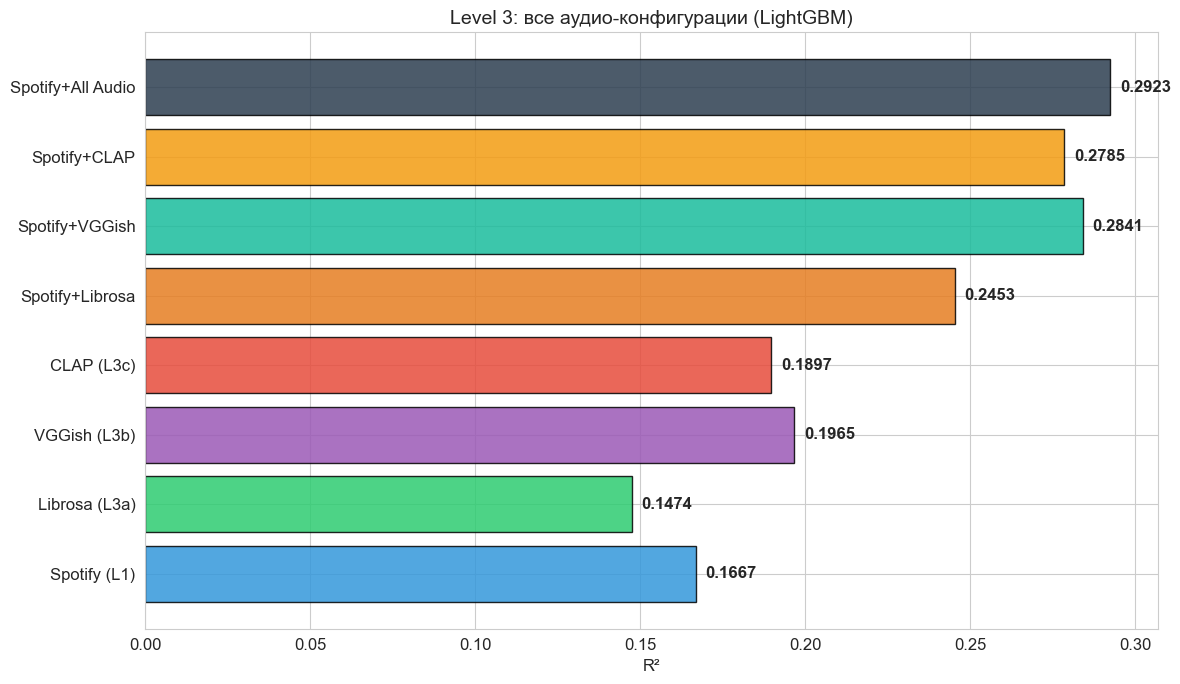

In [16]:
cnames = list(configs.keys()); mnames = list(model_types.keys())
best = max(mnames, key=lambda m: np.mean([results_l3[(c,m)]['R2'] for c in cnames]))
print(f'Лучшая модель: {best}\n')
for c in cnames:
    r = results_l3[(c,best)]
    print(f'  {c:25s}  R²={r["R2"]:7.4f}  MAE={r["MAE"]:7.3f}  AUC={r["AUC"]:7.4f}  [{len(configs[c])} фичей]')

# Barh
r2_vals = [results_l3[(c,best)]['R2'] for c in cnames]
colors = ['#3498db','#2ecc71','#9b59b6','#e74c3c','#e67e22','#1abc9c','#f39c12','#2c3e50']
fig, ax = plt.subplots(figsize=(12, 7))
bars = ax.barh(cnames, r2_vals, color=colors[:len(cnames)], edgecolor='black', alpha=0.85)
for bar, v in zip(bars, r2_vals):
    ax.text(v+0.003, bar.get_y()+bar.get_height()/2., f'{v:.4f}', va='center', fontweight='bold')
ax.set_xlabel('R²'); ax.set_title(f'Level 3: все аудио-конфигурации ({best})', fontsize=14)
plt.tight_layout(); plt.show()

=== Handcrafted vs Learned (3-way) ===
Model                    Librosa      VGGish        CLAP     VGG-Lib    CLAP-Lib
Linear Regression         0.0913      0.1496      0.1741     +0.0583     +0.0828
Random Forest             0.1397      0.2026      0.1882     +0.0629     +0.0485
XGBoost                   0.1450      0.1919      0.1871     +0.0468     +0.0420
LightGBM                  0.1474      0.1965      0.1897     +0.0491     +0.0423


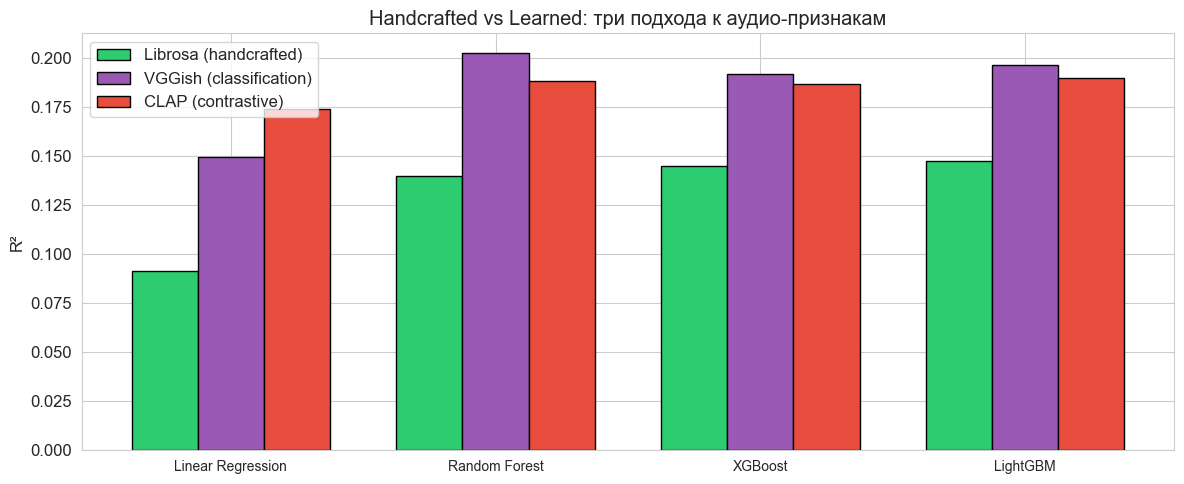

In [17]:
# Handcrafted vs Learned (3-way)
print('=== Handcrafted vs Learned (3-way) ===')
print(f'{"Model":20s}  {"Librosa":>10s}  {"VGGish":>10s}  {"CLAP":>10s}  {"VGG-Lib":>10s}  {"CLAP-Lib":>10s}')
for m in mnames:
    rl = results_l3[('Librosa (L3a)',m)]['R2']
    rv = results_l3[('VGGish (L3b)',m)]['R2']
    rc = results_l3[('CLAP (L3c)',m)]['R2']
    print(f'{m:20s}  {rl:10.4f}  {rv:10.4f}  {rc:10.4f}  {rv-rl:+10.4f}  {rc-rl:+10.4f}')

fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(mnames)); w = 0.25
ax.bar(x-w, [results_l3[('Librosa (L3a)',m)]['R2'] for m in mnames], w, label='Librosa (handcrafted)', color='#2ecc71', edgecolor='black')
ax.bar(x, [results_l3[('VGGish (L3b)',m)]['R2'] for m in mnames], w, label='VGGish (classification)', color='#9b59b6', edgecolor='black')
ax.bar(x+w, [results_l3[('CLAP (L3c)',m)]['R2'] for m in mnames], w, label='CLAP (contrastive)', color='#e74c3c', edgecolor='black')
ax.set_xticks(x); ax.set_xticklabels(mnames, fontsize=10)
ax.set_ylabel('R²'); ax.set_title('Handcrafted vs Learned: три подхода к аудио-признакам')
ax.legend(); plt.tight_layout(); plt.show()

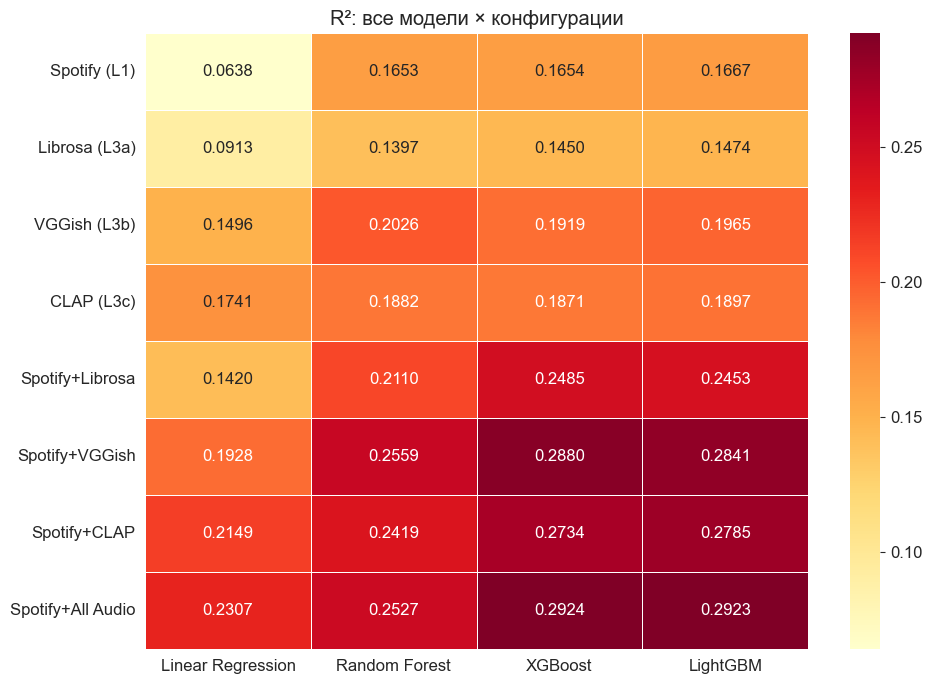

In [18]:
# Тепловая карта
heat = pd.DataFrame({m: [results_l3[(c,m)]['R2'] for c in cnames] for m in mnames}, index=cnames)
fig, ax = plt.subplots(figsize=(10, 7))
sns.heatmap(heat, annot=True, fmt='.4f', cmap='YlOrRd', ax=ax, linewidths=0.5)
ax.set_title('R²: все модели × конфигурации'); plt.tight_layout(); plt.show()

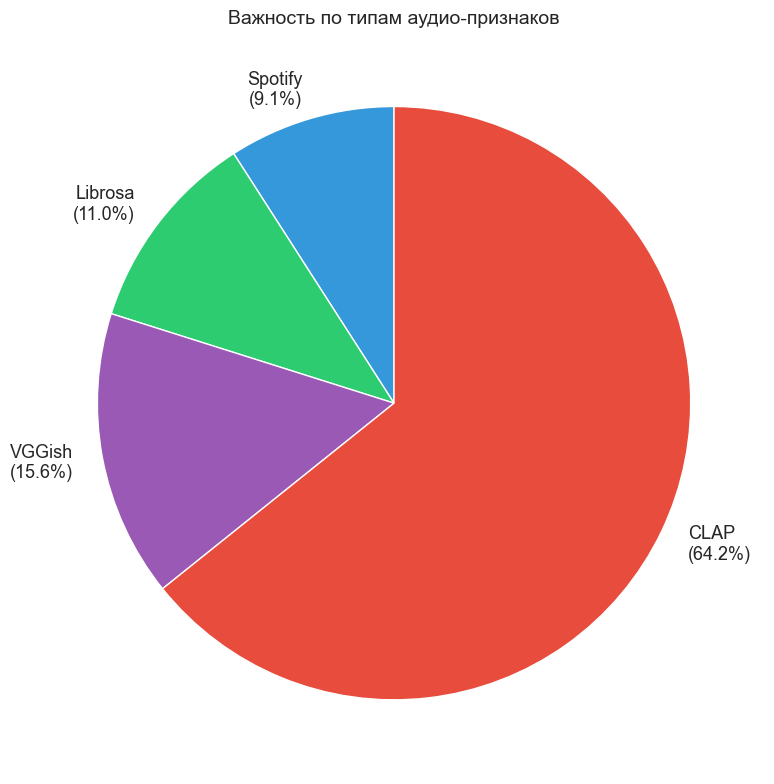

  Spotify: 9.1%
  Librosa: 11.0%
  VGGish: 15.6%
  CLAP: 64.2%


In [19]:
# Feature importance по группам
best_all = results_l3[('Spotify+All Audio', best)]['model']
all_audio_feats = spotify_features + librosa_names + vggish_names + clap_names
if hasattr(best_all, 'feature_importances_'):
    fi = pd.Series(best_all.feature_importances_, index=all_audio_feats)
else:
    fi = pd.Series(np.abs(best_all.coef_), index=all_audio_feats)

groups = {'Spotify': fi[spotify_features].sum(), 'Librosa': fi[librosa_names].sum(),
          'VGGish': fi[vggish_names].sum(), 'CLAP': fi[clap_names].sum()}
total_imp = sum(groups.values())

fig, ax = plt.subplots(figsize=(8, 8))
ax.pie(groups.values(), labels=[f'{k}\n({v/total_imp*100:.1f}%)' for k,v in groups.items()],
       colors=['#3498db','#2ecc71','#9b59b6','#e74c3c'], startangle=90, textprops={'fontsize': 13})
ax.set_title('Важность по типам аудио-признаков', fontsize=14)
plt.tight_layout(); plt.show()

for k,v in groups.items(): print(f'  {k}: {v/total_imp*100:.1f}%')

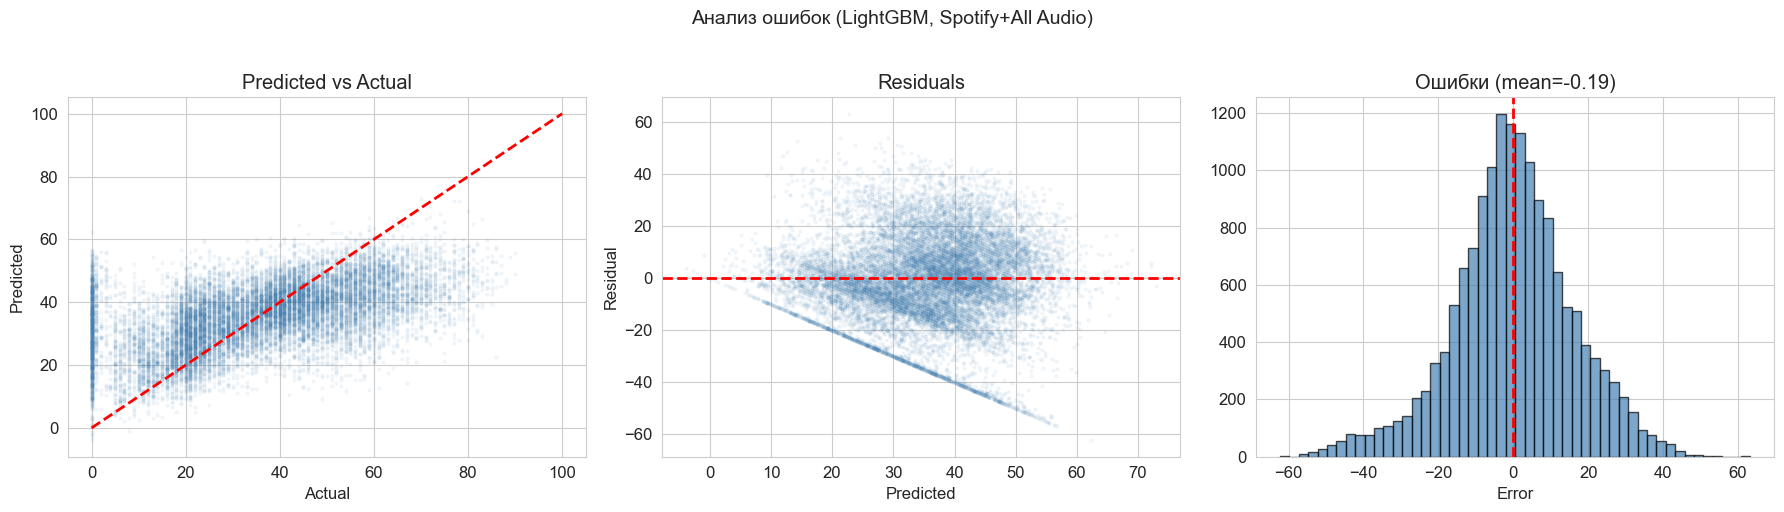

MAE по бинам:
  (-0.09, 18.0]       : MAE= 19.46 (n=2,941.0)
  (18.0, 36.0]        : MAE=  8.31 (n=5,133.0)
  (36.0, 54.0]        : MAE=  7.93 (n=4,779.0)
  (54.0, 72.0]        : MAE= 18.30 (n=2,478.0)
  (72.0, 90.0]        : MAE= 31.64 (n=387.0)


In [20]:
# Анализ ошибок
yp = results_l3[('Spotify+All Audio',best)]['y_pred']
yte = y.iloc[te].values; errors = yte - yp
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].scatter(yte, yp, alpha=0.05, s=5, c='steelblue')
axes[0].plot([0,100],[0,100], 'r--', lw=2)
axes[0].set_xlabel('Actual'); axes[0].set_ylabel('Predicted'); axes[0].set_title('Predicted vs Actual')
axes[1].scatter(yp, errors, alpha=0.05, s=5, c='steelblue')
axes[1].axhline(0, color='r', linestyle='--', lw=2)
axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('Residual'); axes[1].set_title('Residuals')
axes[2].hist(errors, bins=50, color='steelblue', edgecolor='black', alpha=0.7)
axes[2].axvline(0, color='r', linestyle='--', lw=2)
axes[2].set_xlabel('Error'); axes[2].set_title(f'Ошибки (mean={np.mean(errors):.2f})')
plt.suptitle(f'Анализ ошибок ({best}, Spotify+All Audio)', fontsize=14, y=1.02)
plt.tight_layout(); plt.show()

bins_p = pd.cut(yte, bins=5)
df_err = pd.DataFrame({'actual':yte,'predicted':yp,'abs_error':np.abs(errors),'bin':bins_p})
print('MAE по бинам:')
for idx_b, row in df_err.groupby('bin')['abs_error'].agg(['mean','count']).iterrows():
    print(f'  {str(idx_b):20s}: MAE={row["mean"]:6.2f} (n={row["count"]:,})')

---
## 9. Выводы

In [21]:
r2_sp = results_l3[('Spotify (L1)',best)]['R2']
r2_lib = results_l3[('Librosa (L3a)',best)]['R2']
r2_vgg = results_l3[('VGGish (L3b)',best)]['R2']
r2_clap = results_l3[('CLAP (L3c)',best)]['R2']
r2_all = results_l3[('Spotify+All Audio',best)]['R2']

print('='*60)
print(f'ВЫВОДЫ ПО УРОВНЮ 3 ({best})')
print('='*60)
print(f'''
1. ДАННЫЕ:
   Скачано аудио: {len(audio_index_map):,}/{len(df):,} ({len(audio_index_map)/len(df)*100:.1f}%)
   Librosa: {len(librosa_dict):,}, VGGish: {len(vggish_dict):,}, CLAP: {len(clap_dict):,}
   Пересечение: {len(common_idx):,}

2. РЕЗУЛЬТАТЫ ({best}):
   Spotify (14):              R² = {r2_sp:.4f}
   Librosa ({len(librosa_names)}, handcrafted):  R² = {r2_lib:.4f}
   VGGish (128, classification): R² = {r2_vgg:.4f}
   CLAP ({clap_dim}, contrastive):    R² = {r2_clap:.4f}
   All Audio combined:        R² = {r2_all:.4f}

3. СРАВНЕНИЕ ПОДХОДОВ:
   VGGish vs Librosa: Δ R² = {r2_vgg-r2_lib:+.4f}
   CLAP vs Librosa:   Δ R² = {r2_clap-r2_lib:+.4f}
   CLAP vs VGGish:    Δ R² = {r2_clap-r2_vgg:+.4f}

4. ВАЖНОСТЬ:
   {', '.join(f'{k}: {v/total_imp*100:.1f}%' for k,v in groups.items())}
''')

res_list = []
for (c,m),r in results_l3.items():
    res_list.append({'Config':c,'Model':m,'R2':round(r['R2'],4),'MAE':round(r['MAE'],3),'RMSE':round(r['RMSE'],3),'AUC':round(r['AUC'],4)})
pd.DataFrame(res_list).to_csv('level3_results.csv', index=False)
print('Сохранено: level3_results.csv, audio_features.csv')

ВЫВОДЫ ПО УРОВНЮ 3 (LightGBM)

1. ДАННЫЕ:
   Скачано аудио: 78,597/81,207 (96.8%)
   Librosa: 78,586, VGGish: 78,586, CLAP: 78,597
   Пересечение: 78,586

2. РЕЗУЛЬТАТЫ (LightGBM):
   Spotify (14):              R² = 0.1667
   Librosa (105, handcrafted):  R² = 0.1474
   VGGish (128, classification): R² = 0.1965
   CLAP (1024, contrastive):    R² = 0.1897
   All Audio combined:        R² = 0.2923

3. СРАВНЕНИЕ ПОДХОДОВ:
   VGGish vs Librosa: Δ R² = +0.0491
   CLAP vs Librosa:   Δ R² = +0.0423
   CLAP vs VGGish:    Δ R² = -0.0068

4. ВАЖНОСТЬ:
   Spotify: 9.1%, Librosa: 11.0%, VGGish: 15.6%, CLAP: 64.2%

Сохранено: level3_results.csv, audio_features.csv
